In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's consider different arrival times at different times of the day.

In [2]:
def get_interarrival_mean(time):

    if time < 120:           # Within the first two hours, 6 customers arrive per minute.
        return 6

    elif time < 300:         # After 5 hours we consider 2 clients per minute
        return 2

    elif time < 420:         # At the end of the day 3 clients every minute
        return 3

    return 5

### Bank Queue Simulation Function

This function simulates a full banking day using a discrete-event queueing model. Customer arrivals follow a non-homogeneous Poisson process with time-dependent arrival rates to represent peak and off-peak periods. Each arriving customer is assigned a service time drawn from an exponential distribution.

The simulation tracks teller availability, customer waiting times, queue abandonment behavior, teller utilization, and financial performance. Customers who face long waiting times may leave the queue before receiving service, introducing a realistic operational constraint.

The function returns key performance indicators (KPIs) including average waiting time, abandonment rate, teller utilization, number of customers served, revenue, operating costs, and daily profit. These metrics are later used in Monte Carlo experiments to evaluate different staffing levels and identify the optimal number of tellers.


In [3]:
# Business assumptions

def simulate_bank_day(sim_time=480, n_tellers=3, mean_service=5):
    arrivals = []
    current_time = 0

    revenue_per_customer = 0.75
    teller_cost = 8.50  # Daily operating cost per teller


  # --------------------------------------------------
    # 1. Generate customer arrivals
    # Non-homogeneous Poisson process with varying
    # arrival rates throughout the day
    # --------------------------------------------------


    while current_time < sim_time:
        mean_interarrival = get_interarrival_mean(current_time)
        interarrival = np.random.exponential(mean_interarrival)
        current_time += interarrival
        if current_time <= sim_time:
            arrivals.append(current_time)

    total_arrivals = len(arrivals)

    # Handle edge case with no arrivals
    if total_arrivals == 0:
        return {"customers": 0, "served_customers": 0, "profit": -n_tellers * teller_cost}

    # Generate service times for each customer
    service_times = np.random.exponential(mean_service, total_arrivals)

    # Initialize teller status
    tellers = [0.0] * n_tellers
    busy_time = [0.0] * n_tellers
    served_waiting_times = []
    abandoned_count = 0

    # --------------------------------------------------
    # 2. Simulate queue dynamics
    # --------------------------------------------------
    for arrival, service in zip(arrivals, service_times):
        # Select the teller that becomes available first
        teller_idx = np.argmin(tellers)

        available_at = tellers[teller_idx]
        # Calculate the customer's expected waiting time

        total_waited = 0
        virtual_wait = max(0.0, available_at - arrival)

        # Customer abandonment behavior
        # Customers waiting more than 15 minutes
        # have a 60% probability of leaving the queue

        if virtual_wait > 0:
            total_waited += 1


        if virtual_wait > 15 and np.random.rand() < 0.6:
            abandoned_count += 1
            continue

        # Customer remains in the system
        start_service = max(arrival, available_at)
        wait = start_service - arrival
        end_service = start_service + service

        # Update teller availability and workload
        tellers[teller_idx] = end_service
        busy_time[teller_idx] += service
        served_waiting_times.append(wait)

    # --------------------------------------------------
    # 3. Calculate operational KPIs
    # --------------------------------------------------
    served_waiting_times = np.array(served_waiting_times)
    served_customers = len(served_waiting_times)
    pct_waiting = (total_waited / total_arrivals * 100) if total_arrivals > 0 else 0

    abandonment_rate = (abandoned_count / total_arrivals * 100) if total_arrivals > 0 else 0

    # Teller utilization rate
    utilization = [min(busy / sim_time, 1.0) for busy in busy_time]
    avg_utilization = np.mean(utilization)

    # Financial metrics
    revenue = served_customers * revenue_per_customer
    operating_cost = n_tellers * teller_cost
    profit = revenue - operating_cost

    # Service-level KPIs
    pct_wait_over_10 = (served_waiting_times > 10).mean() * 100 if served_customers > 0 else 0
    pct_waiting = (served_waiting_times > 0).mean() * 100 if served_customers > 0 else 0

    return {
        "customers": total_arrivals,
        "served_customers": served_customers,
        "abandoned_customers": abandoned_count,
        "abandonment_rate": abandonment_rate,
        "avg_wait": served_waiting_times.mean() if served_customers > 0 else 0,
        "max_wait": served_waiting_times.max() if served_customers > 0 else 0,
        "pct_waiting": pct_waiting,
        "pct_wait_over_10": pct_wait_over_10,
        "avg_utilization": avg_utilization,
        "revenue": revenue,
        "operating_cost": operating_cost,
        "profit": profit
    }

### Monte Carlo Simulation Across Staffing Scenarios

This section evaluates multiple staffing configurations by running 1,000 independent Monte Carlo simulations for each scenario (2, 3, 4, and 5 tellers).

For every staffing level, the simulation collects operational and financial KPIs, including waiting times, customer abandonment, teller utilization, revenue, operating costs, and profit. The results are then aggregated to estimate the expected performance of each configuration.

In addition to average metrics, the analysis calculates the 95th percentile of maximum waiting times, providing insight into worst-case service conditions. Both the aggregated results and the individual simulation runs are preserved for further statistical analysis and visualization, including profit distributions, volatility assessments, and staffing optimization.


In [4]:
# --------------------------------------------------
# Define staffing scenarios to evaluate
# --------------------------------------------------
scenarios = [2, 3, 4, 5]

# Containers for simulation outputs
summary_data = []
all_runs = []
summary = []
scenario_results = []

# --------------------------------------------------
# Run Monte Carlo simulations for each scenario
# --------------------------------------------------

for tellers in scenarios:
    # Execute 1,000 independent simulations
    # and store results in a temporary DataFrame
    df_temp = pd.DataFrame([simulate_bank_day(n_tellers=tellers) for _ in range(1000)])

    # Tag results with staffing level
    df_temp['tellers'] = tellers

    # Store all individual simulation runs
    # for distribution and risk analysis
    all_runs.append(df_temp)


    # Calculate selected service-level KPIs
    summary.append({
        "tellers": tellers,
        # Average waiting time across simulations
        "avg_wait": df_temp["avg_wait"].mean(),
        # 95th percentile of maximum waiting time
        # Represents an extreme service scenario
        "p95_wait": df_temp["max_wait"].quantile(0.95) # Worst scenario!
    })


    # Calculate average performance metrics
    # across all Monte Carlo runs
    means = df_temp.mean(numeric_only=True)
    means['tellers'] = tellers
    summary_data.append(means)

# --------------------------------------------------
# Consolidate results into final DataFrames
# --------------------------------------------------

# Average KPI values by staffing scenario
summary_df = pd.DataFrame(summary_data)
# Complete dataset containing every simulation
df_all_runs = pd.concat(all_runs, ignore_index=True)
# Service-level summary metrics
df_summary = pd.DataFrame(summary)

In [5]:
summary_df

,customers,served_customers,abandoned_customers,abandonment_rate,avg_wait,max_wait,pct_waiting,pct_wait_over_10,avg_utilization,revenue,operating_cost,profit,tellers
0,161.521,141.338,20.183,12.269608,6.665471,24.365744,71.536958,31.994495,0.734811,106.00350,17.0,89.00350,2.0
1,161.272,159.168,2.104,1.249351,2.277149,13.985939,43.237335,6.970138,0.552841,119.37600,25.5,93.87600,3.0
2,160.677,160.595,0.082,0.046914,0.610302,7.213498,20.100758,0.710267,0.419420,120.44625,34.0,86.44625,4.0
3,160.350,160.348,0.002,0.001266,0.140108,3.525141,7.423936,0.034564,0.334452,120.26100,42.5,77.76100,5.0


### Impact of Staffing Levels on Customer Waiting Time

This chart shows the relationship between the number of tellers and the average customer waiting time, based on 1,000 Monte Carlo simulations per staffing scenario.

As staffing levels increase, waiting times decrease significantly due to the additional service capacity. However, the largest improvement occurs when moving from two to three tellers. Beyond this point, additional tellers provide diminishing operational benefits, as average waiting times become relatively low and further reductions are marginal.

The results highlight the trade-off between service quality and operational costs, demonstrating that while larger staffing levels improve customer experience, they may not always be economically justified.

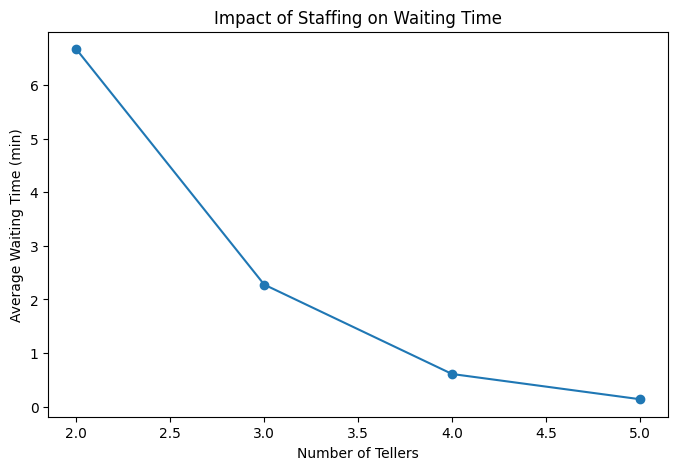

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    summary_df["tellers"],
    summary_df["avg_wait"],
    marker="o"
)

plt.xlabel("Number of Tellers")
plt.ylabel("Average Waiting Time (min)")
plt.title("Impact of Staffing on Waiting Time")
plt.savefig("Impact_of_Staffing_on_Waiting_Time.png", dpi=300, bbox_inches='tight')

plt.show()

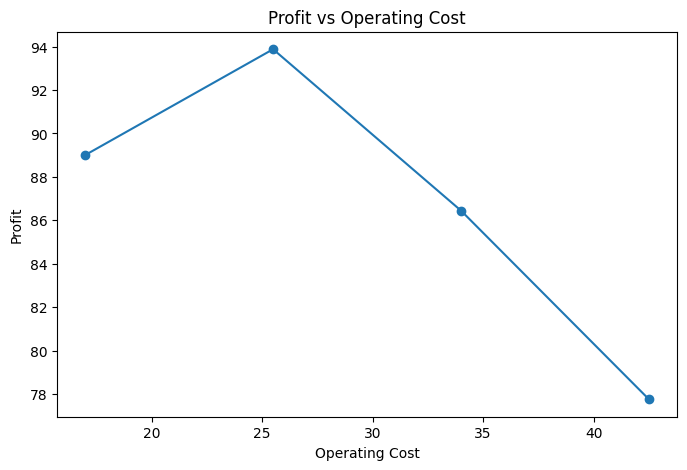

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    summary_df["operating_cost"],
    summary_df["profit"],
    marker="o"
)

plt.xlabel("Operating Cost")
plt.ylabel("Profit")
plt.title("Profit vs Operating Cost")

plt.savefig("Profit_vs_Operating_Cost.png", dpi=300, bbox_inches='tight')

plt.show()

### Profit by Number of Tellers

This chart illustrates the relationship between staffing levels and daily profit, based on 1,000 Monte Carlo simulations for each scenario.

Profit initially increases as additional tellers reduce customer abandonment and allow more transactions to be completed. The transition from two to three tellers generates the largest financial improvement, as the increase in revenue outweighs the additional operating cost.

However, beyond three tellers, profit begins to decline. Although waiting times and abandonment rates continue to improve, the number of additional customers served becomes marginal while operating costs continue to rise. This demonstrates the principle of diminishing returns, where additional resources provide progressively smaller benefits.

The results suggest that three tellers represent the optimal staffing level, achieving the highest average profit while maintaining an efficient balance between service quality and operational costs.


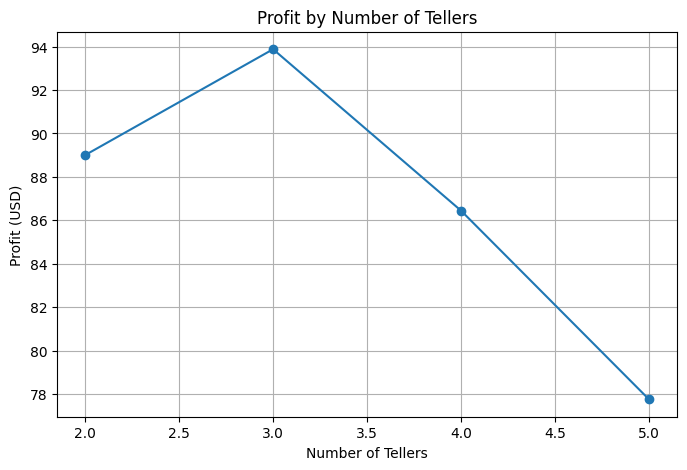

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    summary_df["tellers"],
    summary_df["profit"],
    marker="o"
)

plt.xlabel("Number of Tellers")
plt.ylabel("Profit (USD)")
plt.title("Profit by Number of Tellers")

plt.grid(True)

plt.show()

### Profit and Customer Abandonment by Staffing Level

This chart compares average daily profit and customer abandonment rates across different staffing configurations

As the number of tellers increases, customer abandonment decreases sharply due to shorter queues and reduced waiting times. The most significant improvement occurs when moving from two to three tellers, where abandonment is reduced substantially while profit reaches its highest level.

Beyond three tellers, abandonment rates approach zero, indicating that nearly all customers are served. However, the additional reduction in abandonment generates only a small increase in completed transactions, while operating costs continue to rise. As a result, profitability begins to decline despite continued improvements in service quality.

This comparison highlights the trade-off between customer experience and operational efficiency, showing that the staffing level that minimizes abandonment is not necessarily the one that maximizes profit.


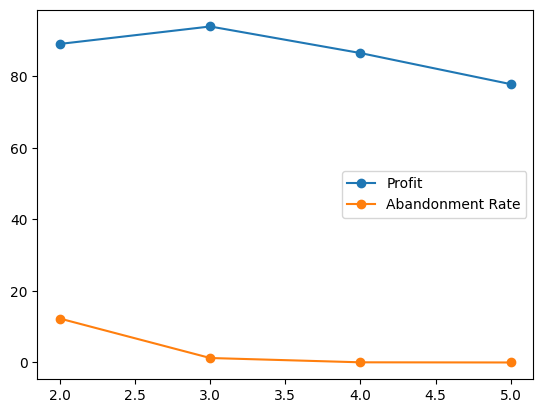

In [9]:
plt.plot(
    summary_df["tellers"],
    summary_df["profit"],
    marker="o",
    label="Profit"
)

plt.plot(
    summary_df["tellers"],
    summary_df["abandonment_rate"],
    marker="o",
    label="Abandonment Rate"
)

plt.legend()

### Customers Served by Staffing Level

Increasing the number of tellers improves the bank's service capacity and reduces customer abandonment, leading to a higher number of completed transactions. The largest gain occurs when moving from two to three tellers, where the reduction in queue congestion allows significantly more customers to be served.

However, the rate of improvement decreases as additional tellers are added. Beyond three tellers, the number of customers served begins to plateau, indicating that most incoming demand is already being met. This suggests that further staffing increases provide limited operational benefits while continuing to increase operating costs.

The results illustrate the principle of diminishing returns, where additional service capacity yields progressively smaller improvements in customer throughput.


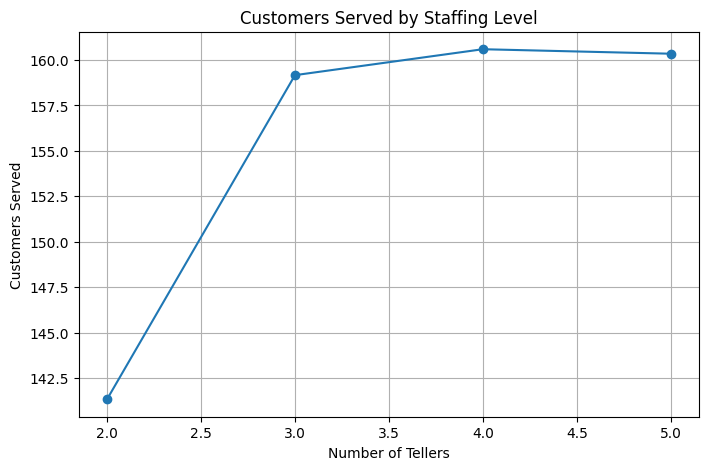

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    summary_df["tellers"],
    summary_df["served_customers"],
    marker="o"
)

plt.xlabel("Number of Tellers")
plt.ylabel("Customers Served")
plt.title("Customers Served by Staffing Level")

plt.grid(True)

plt.show()

### Profit Distribution by Staffing Level
Unlike average-based charts, this visualization captures both the expected profit and the variability of outcomes. The width of each violin represents the density of simulation results, highlighting the range of profits that may occur under different operational conditions.

The three-teller configuration achieves the highest average profit while maintaining a relatively stable distribution. In contrast, two tellers produce more variable outcomes due to higher customer abandonment and queue congestion, while four and five tellers generate lower profits because the additional operating costs outweigh the marginal gains in customers served.

By visualizing the entire distribution rather than a single average value, the chart provides insight into both profitability and operational risk, allowing for a more comprehensive evaluation of staffing decisions.


/tmp/ipykernel_56219/2676155473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


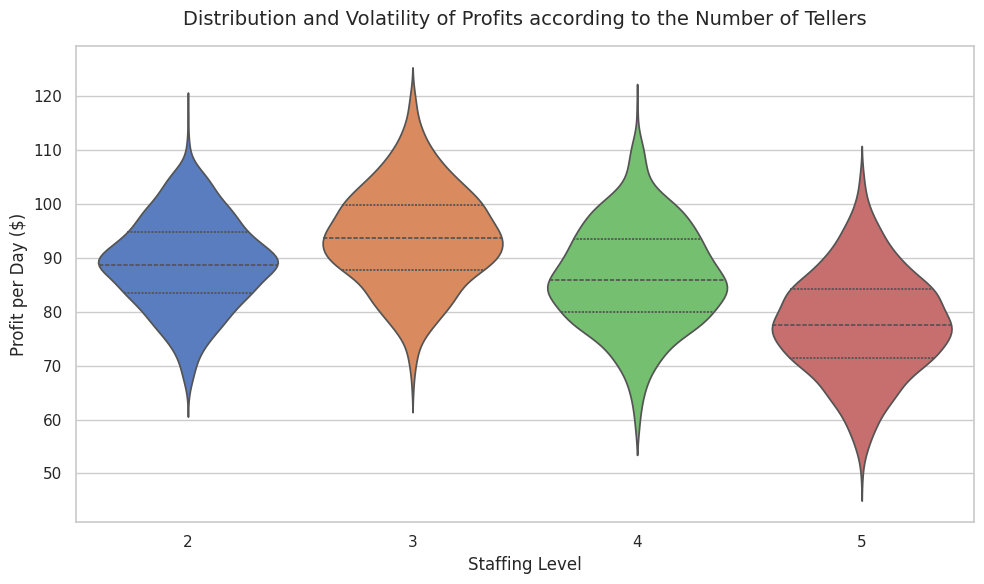

In [11]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.violinplot(
    data=df_all_runs,
    x='tellers',
    y='profit',
    palette="muted",
    inner="quartile"
)

plt.title('Distribution and Volatility of Profits according to the Number of Tellers', fontsize=14, pad=15)
plt.xlabel('Staffing Level', fontsize=12)
plt.ylabel('Profit per Day ($)', fontsize=12)
plt.tight_layout()
plt.savefig("Distribution_and_Volatility_of_Profits_according_to_the_Number_of_Tellers.png", dpi=300, bbox_inches='tight')
plt.show()

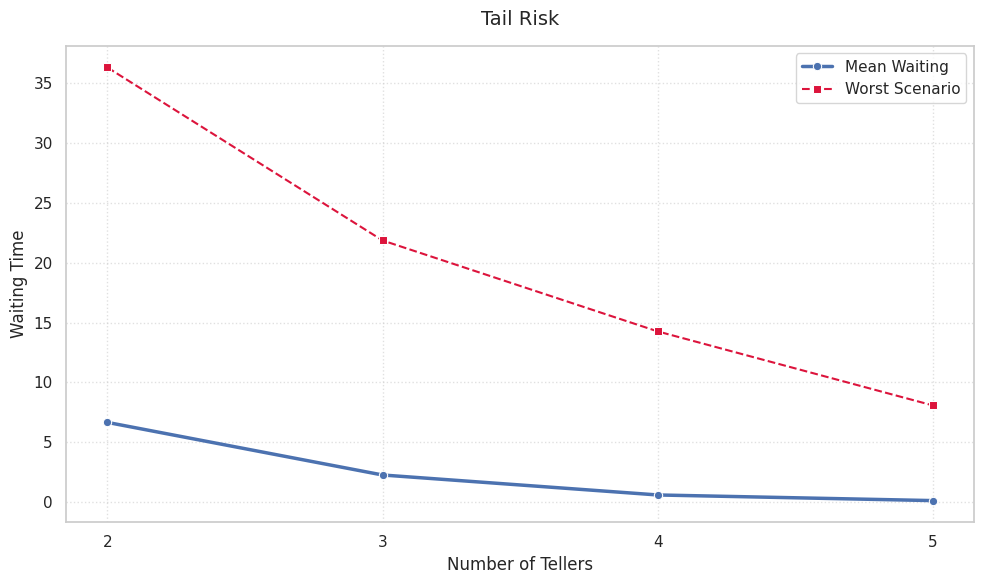

In [12]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=df_summary, x='tellers', y='avg_wait', marker='o', label='Mean Waiting', linewidth=2.5)
sns.lineplot(data=df_summary, x='tellers', y='p95_wait', marker='s', label='Worst Scenario', color='crimson', linestyle='--')

plt.title('Tail Risk', fontsize=14, pad=15)
plt.xlabel('Number of Tellers', fontsize=12)
plt.ylabel('Waiting Time', fontsize=12)
plt.xticks([2, 3, 4, 5])
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig("tail_risk.png", dpi=300, bbox_inches='tight')
plt.show()

##Red Line (Tail Risk):
reveals the truth: on high-volatility days (the 5% worst-case scenarios), customers experience waits of more than 35 minutes! This would destroy customer retention and trigger churn.

## The Critical Tipping Point (3 Tellers):
By moving from 2 to 3 tellers, you achieve the most dramatic system impact. You reduce the worst-case scenario from 36 to about 20 minutes (an improvement of almost 45%), while keeping the average wait below 3 minutes.

## Diminishing Returns (4 vs. 5 Tellers):
Notice how between 4 and 5 tellers, the blue line is already completely flat (close to zero). Adding the fifth teller barely reduces the average wait, but it will increase the bank's fixed costs linearly.